
# **CSCI 5612-872: Machine Learning for DTSC**
##### **Project Topic :** Wine Quality Prediction
##### **Student Name :** Dnyanada Bhosale
##### **Dataset URL :** https://archive.ics.uci.edu/dataset/186/wine+quality
##### **API URL (Grapeminds):**  "https://api.grapeminds.eu/public/v1"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df1=pd.read_csv('winequality-red.csv', sep=';')
df1.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df2=pd.read_csv('winequality-white.csv',sep=';')
df2.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
df1['type'] = 'red'
df2['type'] = 'white'

df3 = pd.concat([df1, df2], ignore_index=True)
df3.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [ ]:
df3.to_csv('winequality_merged.csv', index=False)
df_final= pd.read_csv('winequality_merged.csv')
df_final.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


#### Data collection using API from Grapeminds-api.

In [ ]:
import requests

# Define API Key and Base URL
API_KEY = 'GMOVLPNQQZLX-IoMM0niKLdGD4S8Tx3b5SLDvEcjxQhl8uS9ZWTUkOR26R8wU'
BASE_URL = "https://api.grapeminds.eu/public/v1"

headers = {
    "Authorization": f"Bearer {API_KEY}",
    "Accept": "application/json"
}

ping_response = requests.get(f"{BASE_URL}/ping", headers=headers)
print("Ping Status Code:", ping_response.status_code)
print("Ping Response:", ping_response.json())


wines_response = requests.get(f"{BASE_URL}/wines", headers=headers)

if wines_response.status_code == 200:
    wine_data = wines_response.json()
    print("Successfully retrieved wine data!")
    print(wine_data)
else:
    print(f"Error {wines_response.status_code}:", wines_response.text)

Ping Status Code: 200
Ping Response: {'message': 'API authentication successful', 'authenticated_as': {'user_id': 1028, 'user_name': 'Dnyanada Bhosale', 'user_email': 'dnyanabhosale1207@gmail.com'}, 'api_key': {'name': 'ML_project', 'prefix': 'GMOVLPNQQZLX', 'abilities': ['*'], 'rate_limit_per_minute': 60}, 'timestamp': '2026-09-07T03:17:28+02:00'}
Successfully retrieved wine data!
{'data': [{'id': 1, 'lwin': '1000001', 'display_name': 'Schieferkopf, Lieu Dit Buehl Riesling', 'color': 'white', 'type': 'wine', 'sub_type': 'still', 'residual_sugar': None, 'producer': {'id': 1, 'name': 'Schieferkopf', 'title': None, 'display_name': 'Schieferkopf'}, 'region': {'id': 1, 'name': 'Alsace', 'country': 'fr', 'language': 'en'}}, {'id': 2, 'lwin': '1000014', 'display_name': 'Schieferkopf, Riesling Grand Cru, Kastelberg', 'color': 'white', 'type': 'wine', 'sub_type': 'still', 'residual_sugar': None, 'producer': {'id': 1, 'name': 'Schieferkopf', 'title': None, 'display_name': 'Schieferkopf'}, 'regi

In [ ]:
import json

wines_list = wine_data.get('data', [])
df_api = pd.json_normalize(wines_list)
print(df_api.head())
df_api.to_json('grapeminds_wines.json', orient='records', indent=4)
print("API response successfully converted and saved to grapeminds_wines.json!")

   id     lwin                                       display_name  color  \
0   1  1000001              Schieferkopf, Lieu Dit Buehl Riesling  white   
1   2  1000014       Schieferkopf, Riesling Grand Cru, Kastelberg  white   
2   3  1000027                           Schieferkopf, Pinot Gris  white   
3   4  1000030  Schieferkopf, Riesling Grand Cru, Altenberg de...  white   
4   5  1000043                             Schieferkopf, Sylvaner  white   

   type sub_type residual_sugar  producer.id producer.name producer.title  \
0  wine    still           None            1  Schieferkopf           None   
1  wine    still           None            1  Schieferkopf           None   
2  wine    still           None            1  Schieferkopf           None   
3  wine    still           None            1  Schieferkopf           None   
4  wine    still           None            1  Schieferkopf           None   

  producer.display_name  region.id            region.name region.country  \
0   

##### I completed the GrapeMinds API integration by pulling the data and saving it to a JSON file as required. However, that data only has metadata like producer names and regions, not chemical data. Since this assignment requires analyzing wine properties, I am using the merged UCI Wine Quality dataset instead. It includes all the chemical features I need for my analysis—such as acidity, sugar, pH, alcohol, and quality ratings.


#### Exploratory Data Analysis (EDA)

In [ ]:
df_final.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
for col in df_final.columns:
  if df_final[col].isnull().sum() > 0:
    df_final[col] = df_final[col].fillna(df_final[col].mean())

df_final.isnull().sum().sum()

np.int64(0)

In [ ]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [ ]:

print(f"Duplicate rows before: {df_final.duplicated().sum()}")
df_final.drop_duplicates (inplace=True)
print(f"Duplicate rows after cleaning:",df_final.duplicated().sum() )


Duplicate rows before: 1177
Duplicate rows after cleaning: 0


In [ ]:
if 'type' in df_final.columns:
    # Binary encoding: red -> 0, white -> 1
    df_final['type_encoded'] = (df_final['type'] == 'white').astype(int)
    df_final = df_final.drop(columns=['type'])
df_final.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_encoded
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [ ]:
# Continuous chemical features for capping
continuous_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

# Cap outliers to upper and lower IQR bounds
for col in continuous_cols:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_final[col] = np.clip(df_final[col], lower_bound, upper_bound)
df_final.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_encoded
0,7.40,0.68,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.80,0.68,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.80,0.68,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,9.65,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
5,7.40,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [ ]:
# Binary target: 0 = Low/Medium Quality (<= 6), 1 = High Quality (>= 7)
df_final['quality_class'] = (df_final['quality'] >= 7).astype(int)

print(df_final['quality_class'].value_counts())

quality_class
0    4311
1    1009
Name: count, dtype: int64


#### Data Visualizations

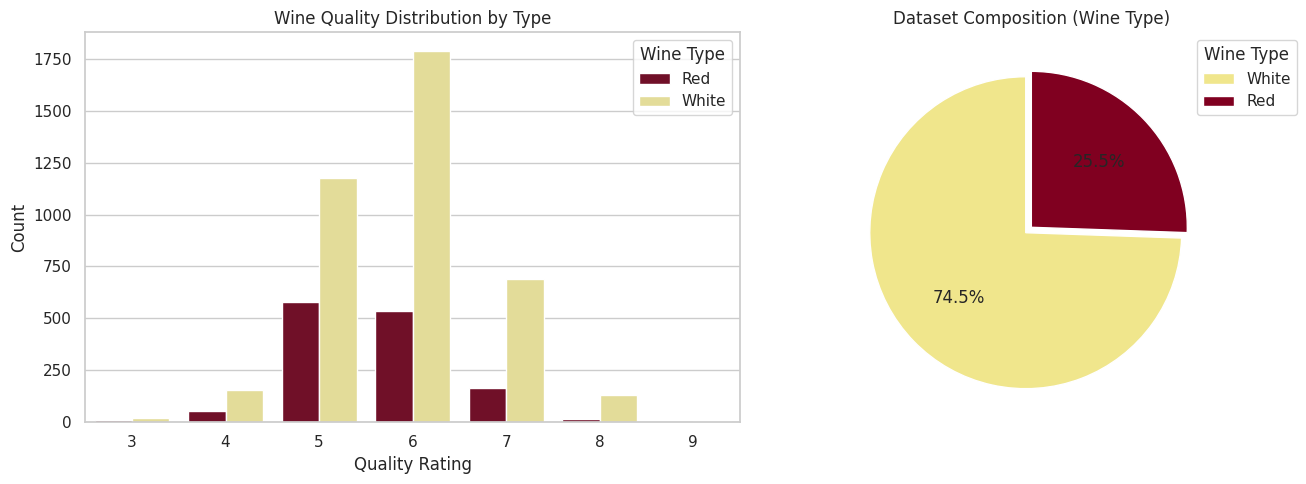

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1.Distribution of Wine Quality across Wine Types
sns.countplot(data=df_final, x='quality', hue='type_encoded', palette=['#800020', '#F0E68C'], ax=axes[0])
axes[0].set_title('Wine Quality Distribution by Type')
axes[0].set_xlabel('Quality Rating')
axes[0].set_ylabel('Count')
handles, labels = axes[0].get_legend_handles_labels()
hue_labels_map = {'0': 'Red', '1': 'White'}
axes[0].legend(handles=handles, labels=[hue_labels_map[label] for label in labels], title="Wine Type")


# 2.Proportion of Red vs. White Wine
type_counts = df_final['type_encoded'].value_counts()
pie_labels_map = {0: 'Red', 1: 'White'}
labels_for_pie_legend = [pie_labels_map[idx] for idx in type_counts.index]
colors_for_pie = ['#F0E68C' if idx == 1 else '#800020' for idx in type_counts.index] # White gets yellow, Red gets maroon


type_counts.plot.pie(
    autopct='%1.1f%%',
    colors=colors_for_pie,
    ax=axes[1],
    startangle=90,
    explode=(0.05, 0),
    labels=['', '']
)


wedges = axes[1].patches

axes[1].set_title('Dataset Composition (Wine Type)')
axes[1].set_ylabel('')

axes[1].legend(
    wedges, labels_for_pie_legend,
    title="Wine Type",
    loc="upper right",
    bbox_to_anchor=(1.2, 1)
)

plt.tight_layout()
plt.show()

##### The countplot wine quality distribution suggests that white wine has high quality rating as compared to red wine. Quality rating for 6 (White wine) is highest among all.

##### The pie chart suggests that white wine contributes to 74.5% of the dataset composition which is majority of the data.


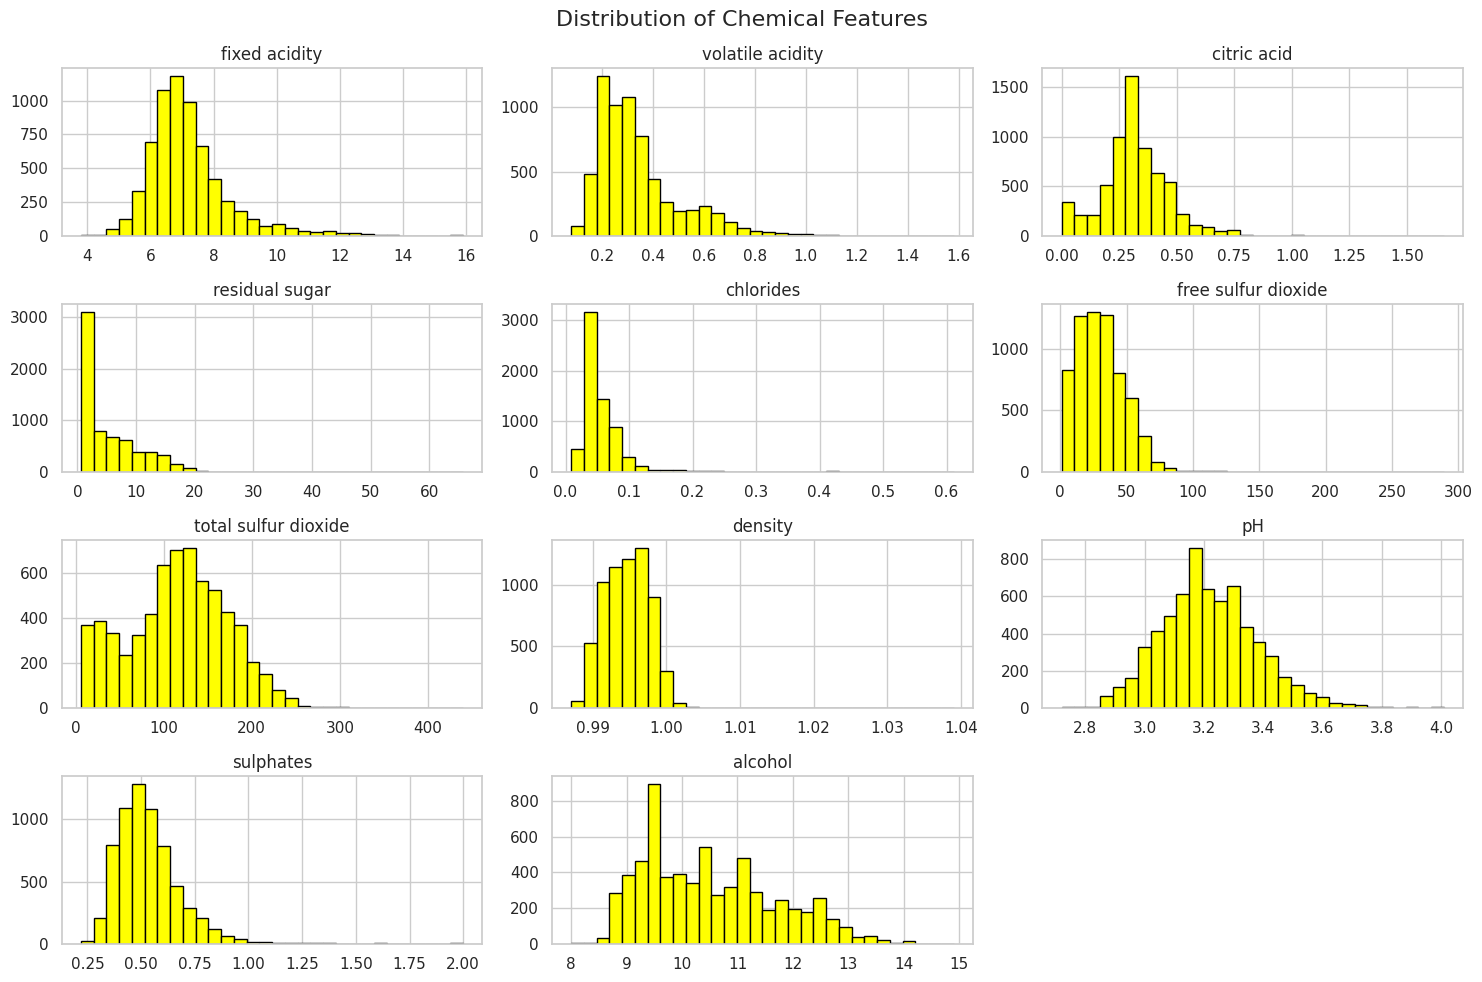

In [ ]:
# 3.Feature Distribution Histogram
features = [col for col in df_final.columns if col not in ['quality', 'type']]

df_final[features].hist(bins=30, figsize=(15, 10), color='yellow', edgecolor='black')
plt.suptitle('Distribution of Chemical Features', fontsize=16)
plt.tight_layout()
plt.show()

##### This multi-panel histogram visualizes the distribution of 11 continuous chemical features from the wine dataset. While features like pH, fixed acidity, and density exhibit roughly bell-shaped (normal) distributions, features such as residual sugar, chlorides, volatile acidity, and sulphates show heavy right-skewness with long upper tails. Additionally, total sulfur dioxide displays a slight bimodal tendency, while alcohol presents an irregular, multi-peaked right-skewed profile.

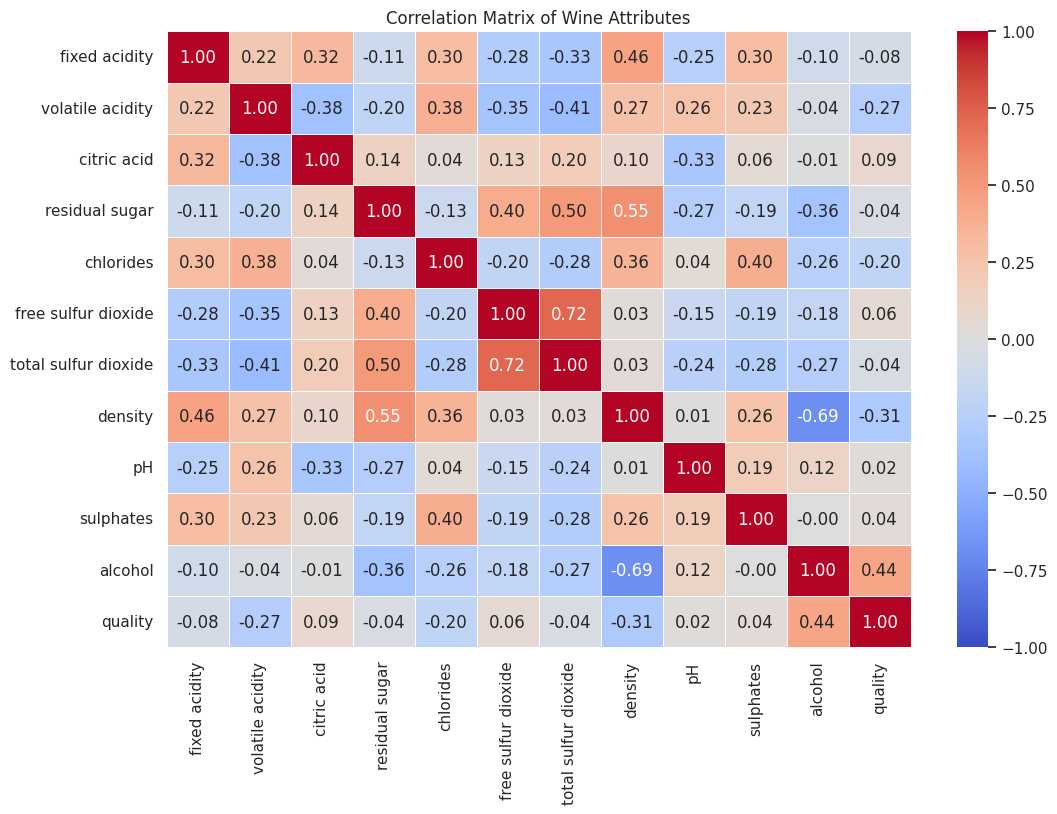

In [ ]:
# 4. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df_final.drop(columns=['type'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Wine Attributes')
plt.show()

##### Citric acid and alcohol are least correlated to each other. Their correlation coefficient is -0.01.Total sulfur dioxide and free sulfur dioxide are highly correlated,show a linear relationship with each other and their correlation coefficient is 0.72.

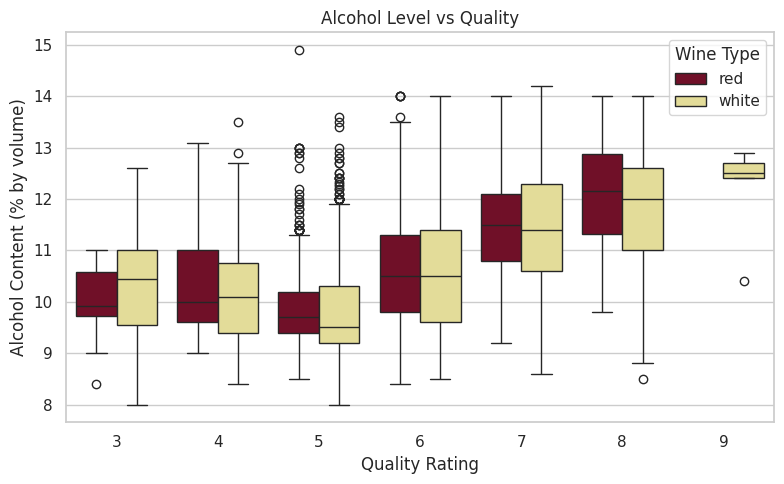

In [ ]:
# 5. Boxplot of Alcohol vs Quality
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x='quality', y='alcohol', hue='type', palette=['#800020', '#F0E68C'])
plt.title('Alcohol Level vs Quality')
plt.xlabel('Quality Rating')
plt.ylabel('Alcohol Content (% by volume)')
plt.legend(title='Wine Type')
plt.tight_layout()
plt.show()

##### The boxplot of quality rating 5 has highest number of outliers. It also has smallest median value as compared to other Quality rating.The boxplot shows a clear positive correlation between alcohol content and wine quality rating across both red and white wines, particularly for quality rating from 5 to 9.

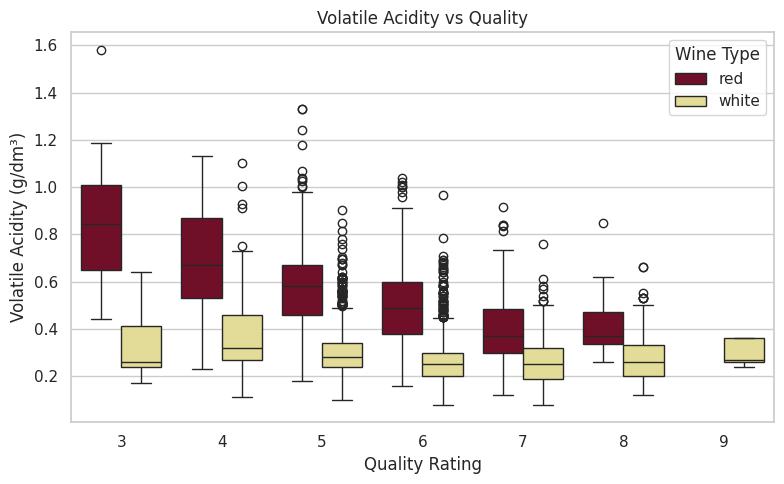

In [ ]:
# 6. Boxplot of Volatile Acidity vs Quality
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x='quality', y='volatile acidity', hue='type', palette=['#800020', '#F0E68C'])
plt.title('Volatile Acidity vs Quality')
plt.xlabel('Quality Rating')
plt.ylabel('Volatile Acidity (g/dm³)')
plt.legend(title='Wine Type')
plt.tight_layout()
plt.show()

##### Quality score 5 contains the heaviest concentration of upper outliers.Quality rating 9 is exclusive to white wine, with a narrow interquartile range (IQR). Red wines consistently exhibit significantly higher volatile acidity levels than white wines across every single quality rating.

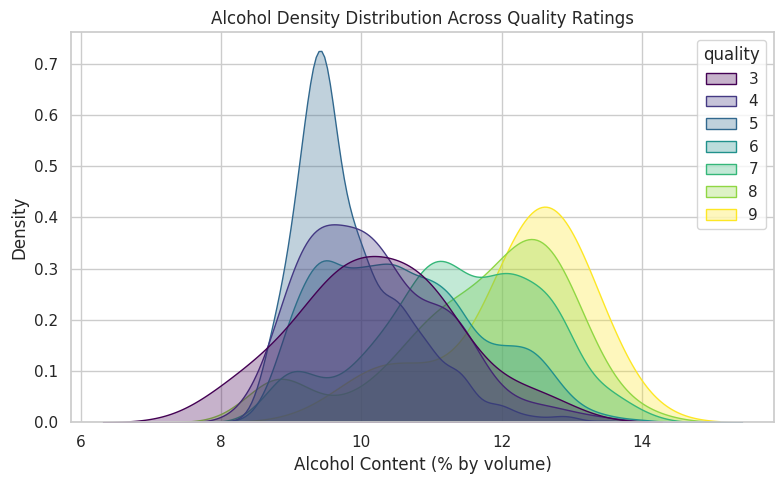

In [ ]:
# 7. Density Plot: Distribution of Alcohol Content by Quality
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_final, x='alcohol', hue='quality', palette='viridis', common_norm=False, fill=True, alpha=0.3)
plt.title('Alcohol Density Distribution Across Quality Ratings')
plt.xlabel('Alcohol Content (% by volume)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

##### As quality ratings increase from 5 to 9, the probability density curves shift distinctly to the right, indicating that higher-rated wines consistently contain higher alcohol percentages. Quality score 5 exhibits a tall, narrow peak centered around ~9.5% alcohol, reaching a density over 0.7. This reflects a highly concentrated sample volume around lower alcohol levels.

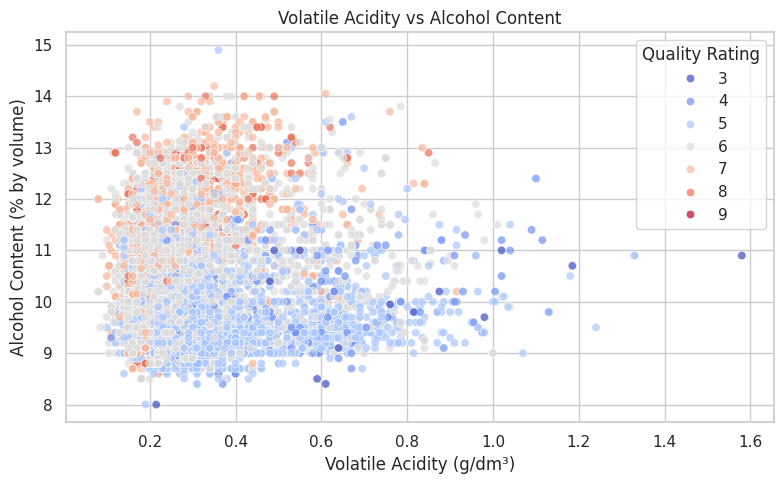

In [ ]:
# 8. Pairwise Scatter Plot: Volatile Acidity vs Alcohol colored by Quality
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_final, x='volatile acidity', y='alcohol', hue='quality', palette='coolwarm', alpha=0.7)
plt.title('Volatile Acidity vs Alcohol Content')
plt.xlabel('Volatile Acidity (g/dm³)')
plt.ylabel('Alcohol Content (% by volume)')
plt.legend(title='Quality Rating')
plt.tight_layout()
plt.show()

##### High-rated wines (scores 7, 8, and 9 in peach and red) cluster heavily in the upper-left region.This indicates that superior wines combine high alcohol content with low volatile acidity.

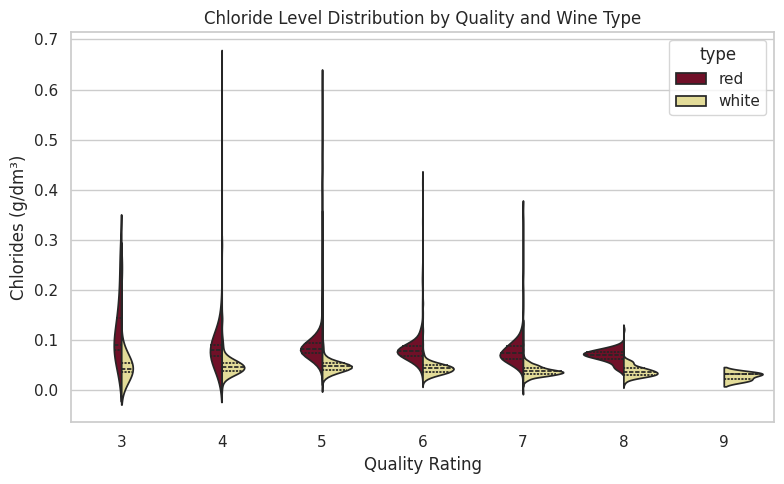

In [ ]:
# 9. Violin Plot: Chloride Levels by Wine Type and Quality
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_final, x='quality', y='chlorides', hue='type', split=True, palette=['#800020', '#F0E68C'], inner='quartile')
plt.title('Chloride Level Distribution by Quality and Wine Type')
plt.xlabel('Quality Rating')
plt.ylabel('Chlorides (g/dm³)')
plt.tight_layout()
plt.show()

##### For red wine, median chloride levels subtly decline as quality improves from score 5 to score 8. For white wine, chloride levels remain consistently low and tightly bound across every rating.

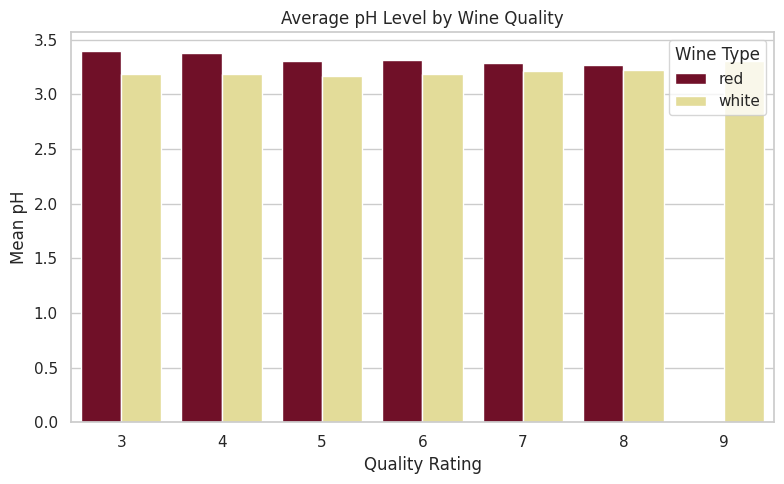

In [ ]:
# 10. Mean pH Level by Wine Quality and Type
plt.figure(figsize=(8, 5))
sns.barplot(data=df_final, x='quality', y='pH', hue='type', palette=['#800020', '#F0E68C'], errorbar=None)
plt.title('Average pH Level by Wine Quality')
plt.xlabel('Quality Rating')
plt.ylabel('Mean pH')
plt.legend(title='Wine Type')
plt.tight_layout()
plt.show()

##### Grouped bar chart displays the average pH levels across quality ratings (3 through 9) for red and white wines. Average pH levels remain uniform regardless of wine quality, staying tightly bounded between 3.15 and 3.40.

#####